# Attention Maps & S2AE-Cluster-Sanity-Check

Extrahiert die Self-Attention des (eingefrorenen) Encoders für ein paar CUB-Beispiele
und visualisiert sie -- einmal als rohe Query-Patch-Attention-Heatmap, einmal als das
tatsächlich von `loss.*.grouping=attention` konsumierte Ergebnis: die
`AgglomerativeClustering`-Segmentierung aus `attention_grouping.py::cluster_patches`.

Zweck: rein explorativ pruefen, ob die Attention-Maps und die daraus abgeleiteten
Gruppen inhaltlich Sinn ergeben (z.B. Vogel vs. Hintergrund, Kopf/Fluegel/Koerper als
separate Gruppen), bevor der volle S2AE-Trainingslauf gestartet wird. Kein Training,
kein Schreiben in den Cache -- nur Anschauen.

In [1]:
import os
from pathlib import Path

import hydra
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from cbm_msae_lab.attention_grouping import cluster_patches
from cbm_msae_lab.config_schema import Config, register_configs

# conf/*.yaml paths (checkpoints/, cache/) are relative to the repo root, not
# to notebooks/ -- match scripts/*.py's implicit assumption (Hydra's
# `hydra.job.chdir: false` only helps `hydra.main`-driven scripts, not this).
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)

register_configs()
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [2]:
# Config wie in `scripts/extract_attention_groups.py`: Hydra-Overrides hier bei Bedarf
# eintragen (z.B. ["encoder=dinov3"]), Default ist CLIP-DINOiser wie im geplanten
# S2AE-Trainingslauf.
overrides: list[str] = []

with hydra.initialize(version_base=None, config_path="../conf"):
    cfg: Config = hydra.compose(config_name="config", overrides=overrides)  # type: ignore[assignment]

n_clusters = cfg.loss.attention_grouping.n_clusters
spatial_coeff = cfg.loss.attention_grouping.spatial_coeff
print(f"encoder={cfg.encoder._target_}, n_clusters={n_clusters}, spatial_coeff={spatial_coeff}")

encoder=cbm_msae_lab.encoders.clip_dinoiser.ClipDinoiserEncoder, n_clusters=20, spatial_coeff=0.02


/home/faroesch/workspace/cbm_msae_lab/.venv/lib/python3.11/site-packages/IPython/core/async_helpers.py:140: UserWarning: 
'encoder/clip_dinoiser' is validated against ConfigStore schema with the same name.
This behavior is deprecated in Hydra 1.1 and will be removed in Hydra 1.2.
See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/automatic_schema_matching for migration instructions.
  coro.send(None)
/home/faroesch/workspace/cbm_msae_lab/.venv/lib/python3.11/site-packages/IPython/core/async_helpers.py:140: UserWarning: 
'projection/k3' is validated against ConfigStore schema with the same name.
This behavior is deprecated in Hydra 1.1 and will be removed in Hydra 1.2.
See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/automatic_schema_matching for migration instructions.
  coro.send(None)
/home/faroesch/workspace/cbm_msae_lab/.venv/lib/python3.11/site-packages/IPython/core/async_helpers.py:140: UserWarning: 
'upsampler/none' is validated against ConfigStore schema with the same name.
Thi

In [3]:
encoder = hydra.utils.instantiate(cfg.encoder, extract_attention=True).to(device)
encoder.eval()

dataset = hydra.utils.instantiate(cfg.dataset, split="test")
len(dataset)

5794

In [4]:
# Nur ein paar Beispiele -- Indizes hier anpassen, um andere Bilder zu sehen.
example_indices = [0, 200, 800, 1500]

images = torch.stack([dataset[i][0] for i in example_indices]).to(device)  # [N, 3, H, W]
with torch.no_grad():
    out = encoder(images)

attention = out.attention  # [N, P, P]
grid_h, grid_w = out.features.shape[-2], out.features.shape[-1]
assert attention is not None, "encoder did not return attention -- check extract_attention=True"
print(f"images={images.shape}, attention={attention.shape}, grid={grid_h}x{grid_w}")

images=torch.Size([4, 3, 224, 224]), attention=torch.Size([4, 196, 196]), grid=14x14


## Rohe Query-Patch-Attention

Fuer einen gewaehlten Query-Patch (Standard: Grid-Mitte, meist Vogel-Koerper bei CUB)
wird die Zeile der Attention-Matrix -- "worauf schaut dieser Patch?" -- als Heatmap
ueber das Bild gelegt.

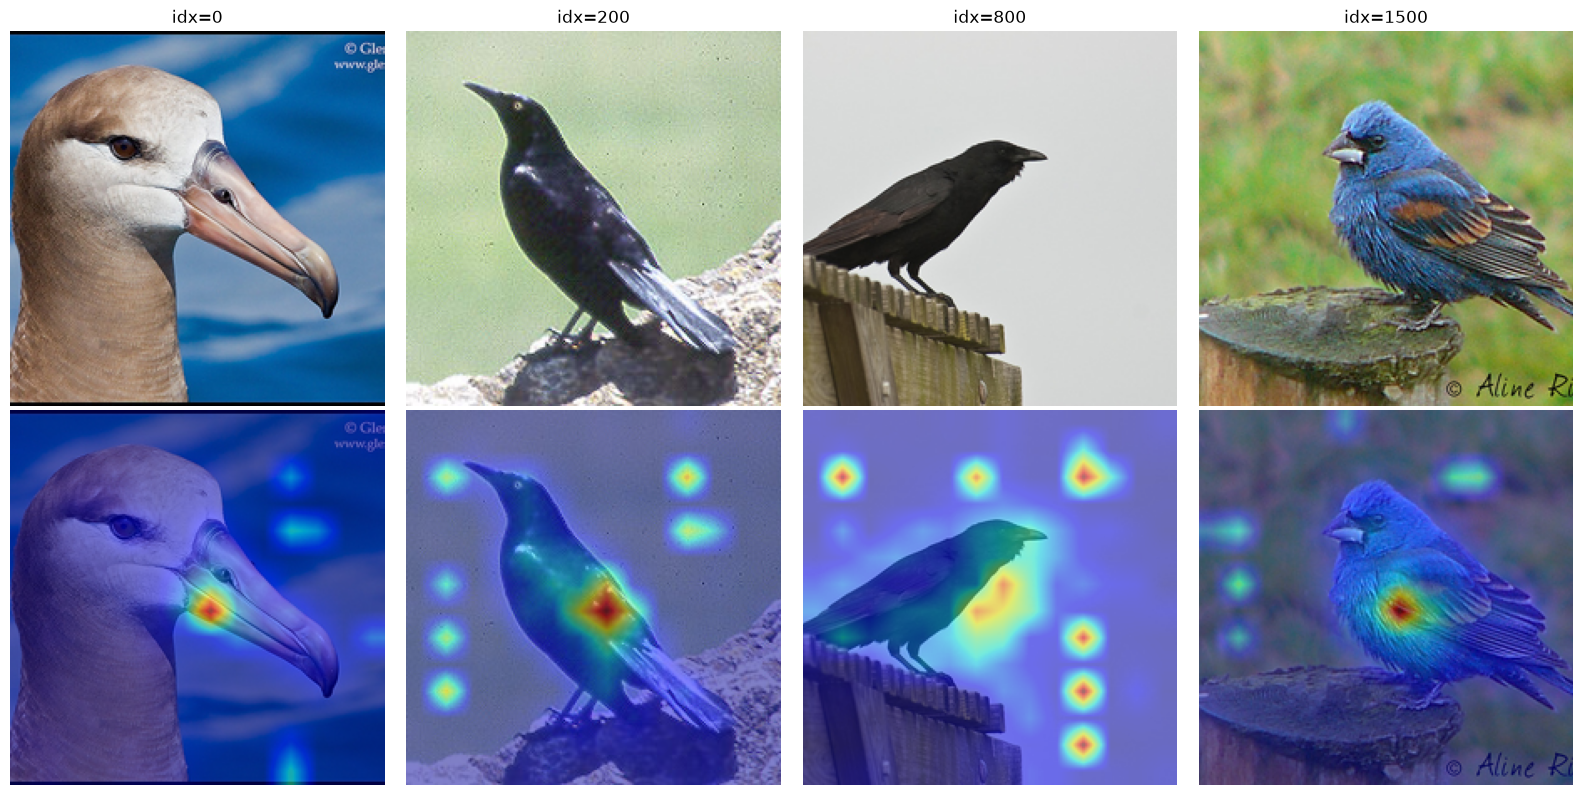

In [5]:
def attention_heatmap(attn_row: torch.Tensor, grid_h: int, grid_w: int, image_size: int) -> torch.Tensor:
    """attn_row: [P] -> [image_size, image_size], normalized to [0, 1], upsampled bilinear."""
    grid = attn_row.reshape(1, 1, grid_h, grid_w)
    grid = (grid - grid.min()) / (grid.max() - grid.min() + 1e-12)
    return F.interpolate(grid, size=(image_size, image_size), mode="bilinear", align_corners=False)[0, 0]


query_patch = (grid_h // 2) * grid_w + (grid_w // 2)  # Grid-Mitte
image_size = images.shape[-1]

fig, axes = plt.subplots(2, len(example_indices), figsize=(4 * len(example_indices), 8))
for col, idx in enumerate(example_indices):
    img = images[col].permute(1, 2, 0).cpu().numpy()
    heat = attention_heatmap(attention[col, query_patch], grid_h, grid_w, image_size).cpu().numpy()

    axes[0, col].imshow(img)
    axes[0, col].set_title(f"idx={idx}")
    axes[0, col].axis("off")

    axes[1, col].imshow(img)
    axes[1, col].imshow(heat, cmap="jet", alpha=0.5)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Attention (Query = Grid-Mitte)")
fig.tight_layout()

## S2AE-Cluster-Segmentierung

Das ist die Groesse, die `loss.group_sparsity.grouping=attention` /
`loss.exclusivity.grouping=attention` tatsaechlich verwendet (siehe
`attention_grouping.py::cluster_patches`): symmetrisierte Attention + raeumliche
Naehe -> `AgglomerativeClustering`. Hier direkt (ohne Cache) fuer die paar
Beispielbilder berechnet.

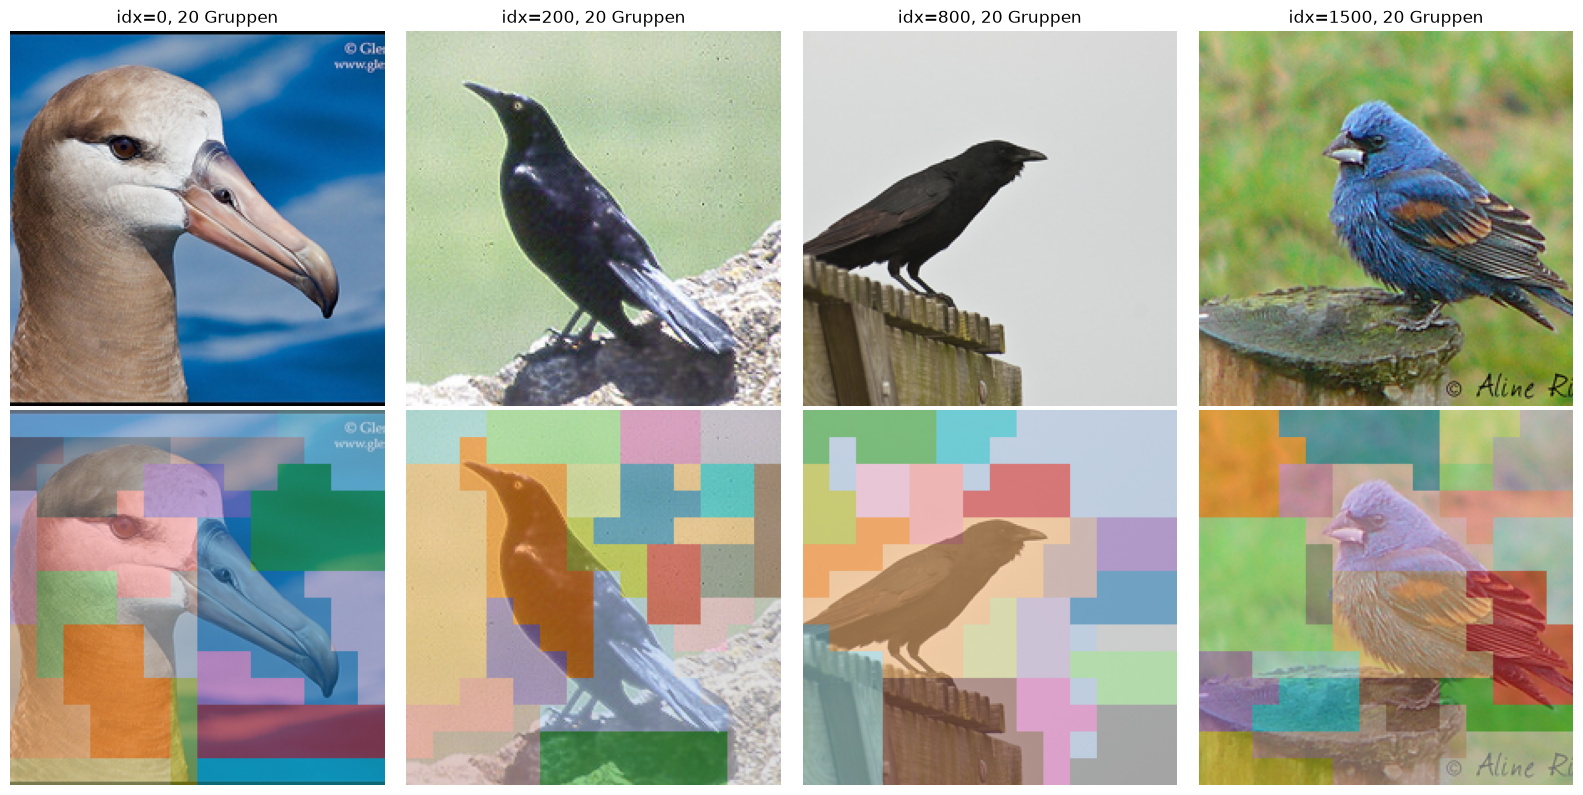

In [6]:
import numpy as np

cmap = plt.get_cmap("tab20", n_clusters)

fig, axes = plt.subplots(2, len(example_indices), figsize=(4 * len(example_indices), 8))
for col, idx in enumerate(example_indices):
    img = images[col].permute(1, 2, 0).cpu().numpy()
    labels = cluster_patches(attention[col], grid_h, grid_w, n_clusters=n_clusters, spatial_coeff=spatial_coeff)
    label_grid = torch.from_numpy(labels.reshape(1, 1, grid_h, grid_w)).float()
    label_grid = F.interpolate(label_grid, size=(image_size, image_size), mode="nearest")[0, 0].numpy()

    axes[0, col].imshow(img)
    axes[0, col].set_title(f"idx={idx}, {len(np.unique(labels))} Gruppen")
    axes[0, col].axis("off")

    axes[1, col].imshow(img)
    axes[1, col].imshow(label_grid, cmap=cmap, alpha=0.55, vmin=0, vmax=n_clusters - 1)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Cluster-Gruppen")
fig.tight_layout()

## Naechste Schritte

- `example_indices` anpassen, um weitere Bilder zu pruefen (z.B. gezielt schwierige
  Faelle: Vogel klein/verdeckt, unruhiger Hintergrund).
- `query_patch` auf einen anderen Patch setzen (z.B. Kopf/Schnabel), um zu sehen, ob
  die Attention dort anders/fokussierter aussieht als in der Grid-Mitte.
- `feature_spatial_coeff` unabhaengig von `spatial_coeff` variieren (z.B. Richtung 0),
  um zu sehen, wie stark raeumliche Naehe die Feature-Cluster noch glaettet.
- Falls die Feature-Cluster im Vergleich sichtbar granularer auf dem Vogel selbst
  differenzieren (Kopf/Fluegel/Koerper statt nur Vogel/Hintergrund), ist das ein
  Argument, `loss.*.grouping` im Code um eine dritte Option `"feature"` zu erweitern,
  statt mit `"attention"` in den vollen S2AE-Lauf zu gehen.

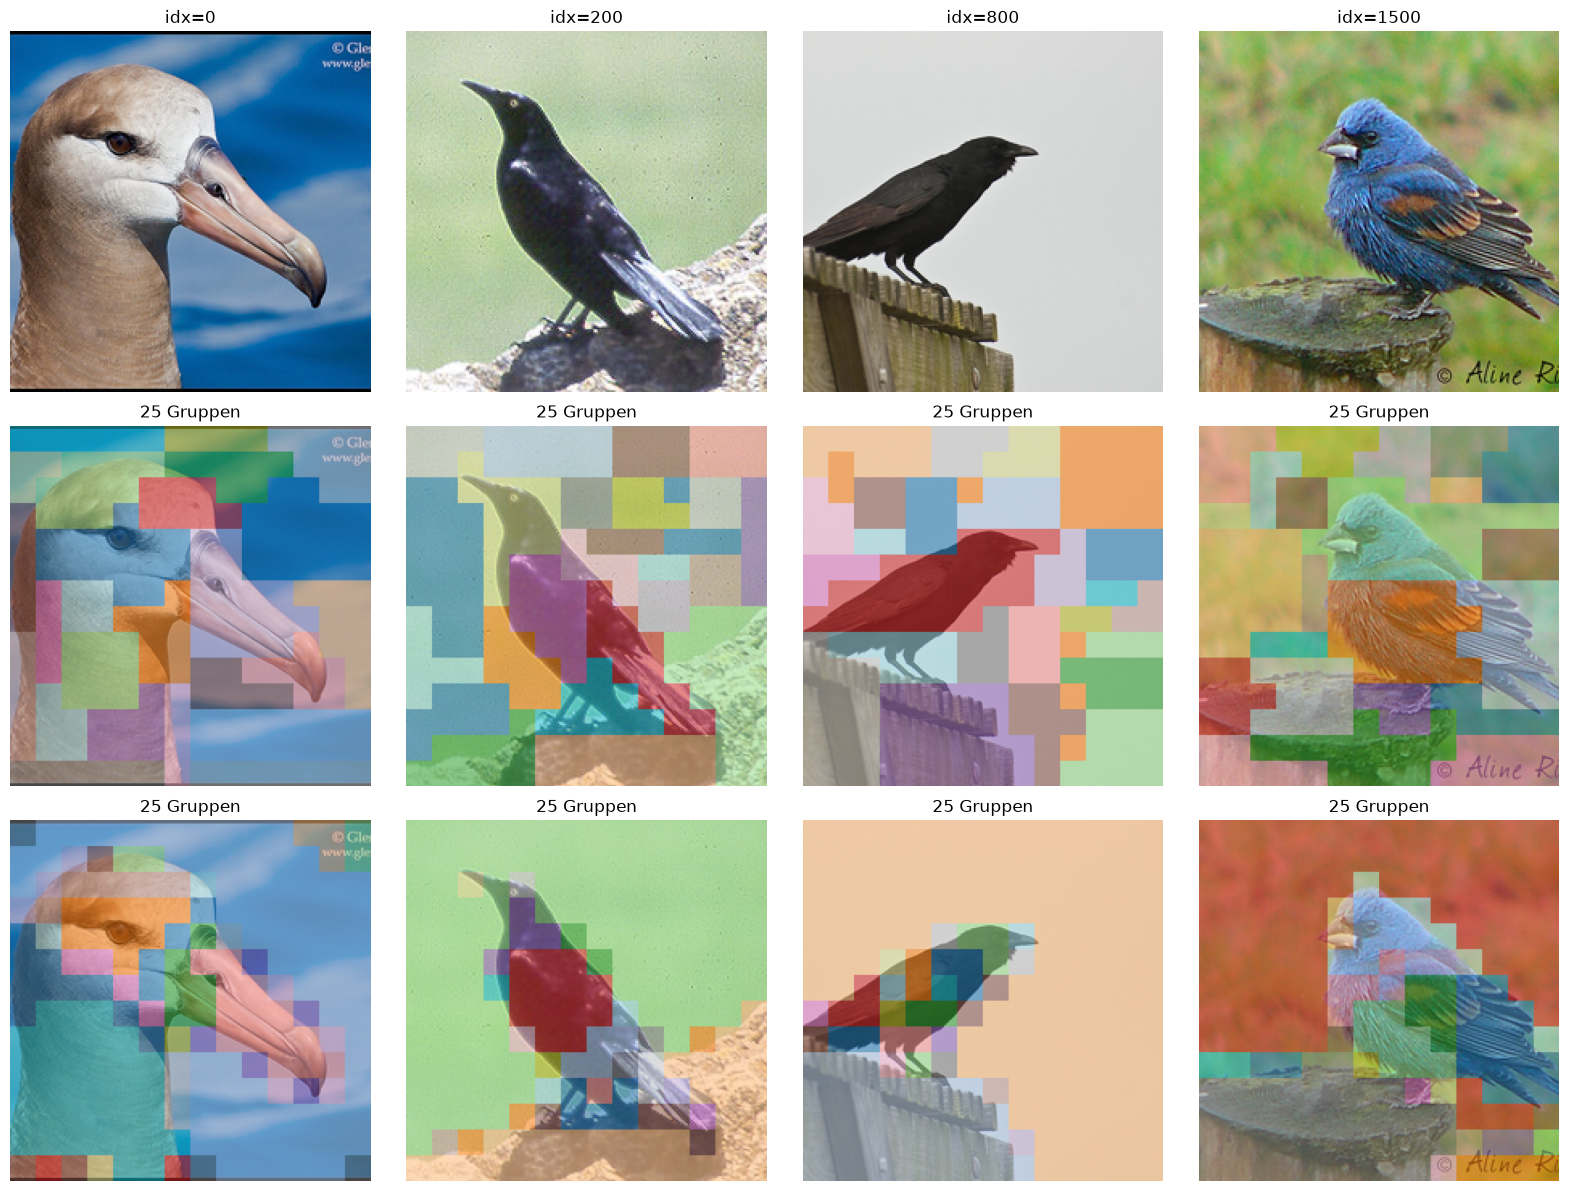

In [12]:
from sklearn.cluster import AgglomerativeClustering


def cluster_patches_by_features(
    features_img: torch.Tensor, grid_h: int, grid_w: int, n_clusters: int = 20, spatial_coeff: float = 0.02
) -> np.ndarray:
    """Wie `attention_grouping.cluster_patches`, aber die Aehnlichkeit kommt aus den
    rohen Encoder-Features statt aus der Attention.

    features_img: [C, grid_h, grid_w] -> labels: [P], P = grid_h * grid_w.
    """
    c, h, w = features_img.shape
    f = features_img.reshape(c, h * w).permute(1, 0)  # [P, C]
    f = F.normalize(f, dim=-1)
    sim = (f @ f.T).double().cpu().numpy()  # cosine similarity, [P, P]

    d_feat = 1.0 - sim
    d_feat = (d_feat - d_feat.min()) / (d_feat.max() - d_feat.min() + 1e-12)

    idx = np.arange(h * w)
    rows, cols = idx // w, idx % w
    d_spatial = np.abs(rows[:, None] - rows[None, :]) + np.abs(cols[:, None] - cols[None, :])
    d_spatial = d_spatial / d_spatial.max()

    distance = d_feat * (d_spatial**spatial_coeff)
    agnes = AgglomerativeClustering(n_clusters=min(n_clusters, h * w), metric="precomputed", linkage="average")
    return agnes.fit_predict(distance).astype(np.int64)


# spatial_coeff hier unabhaengig von der Attention-Version einstellbar -- kleiner
# Wert = mehr Gewicht auf reiner Feature-Aehnlichkeit, weniger auf raeumlicher Naehe.
feature_spatial_coeff = spatial_coeff

n_clusters = 25

fig, axes = plt.subplots(3, len(example_indices), figsize=(4 * len(example_indices), 12))
for col, idx in enumerate(example_indices):
    img = images[col].permute(1, 2, 0).cpu().numpy()

    attn_labels = cluster_patches(attention[col], grid_h, grid_w, n_clusters=n_clusters, spatial_coeff=spatial_coeff)
    attn_grid = torch.from_numpy(attn_labels.reshape(1, 1, grid_h, grid_w)).float()
    attn_grid = F.interpolate(attn_grid, size=(image_size, image_size), mode="nearest")[0, 0].numpy()

    feat_labels = cluster_patches_by_features(
        out.features[col], grid_h, grid_w, n_clusters=n_clusters, spatial_coeff=feature_spatial_coeff
    )
    feat_grid = torch.from_numpy(feat_labels.reshape(1, 1, grid_h, grid_w)).float()
    feat_grid = F.interpolate(feat_grid, size=(image_size, image_size), mode="nearest")[0, 0].numpy()

    axes[0, col].imshow(img)
    axes[0, col].set_title(f"idx={idx}")
    axes[0, col].axis("off")

    axes[1, col].imshow(img)
    axes[1, col].imshow(attn_grid, cmap=cmap, alpha=0.55, vmin=0, vmax=n_clusters - 1)
    axes[1, col].set_title(f"{len(np.unique(attn_labels))} Gruppen")
    axes[1, col].axis("off")

    axes[2, col].imshow(img)
    axes[2, col].imshow(feat_grid, cmap=cmap, alpha=0.55, vmin=0, vmax=n_clusters - 1)
    axes[2, col].set_title(f"{len(np.unique(feat_labels))} Gruppen")
    axes[2, col].axis("off")

axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Attention-Cluster")
axes[2, 0].set_ylabel("Feature-Cluster")
fig.tight_layout()

## Naechste Schritte

- `example_indices` anpassen, um weitere Bilder zu pruefen (z.B. gezielt schwierige
  Faelle: Vogel klein/verdeckt, unruhiger Hintergrund).
- `query_patch` auf einen anderen Patch setzen (z.B. Kopf/Schnabel), um zu sehen, ob
  die Attention dort anders/fokussierter aussieht als in der Grid-Mitte.
- Falls die Cluster-Segmentierung visuell keinen Sinn ergibt (z.B. rein raeumlich
  zufaellig, keine Objekt/Hintergrund-Trennung), ist das ein Hinweis, `spatial_coeff`
  zu senken (mehr Gewicht auf Attention relativ zu raeumlicher Naehe) oder `n_clusters`
  zu aendern, bevor der volle S2AE-Lauf gestartet wird.